<a href="https://colab.research.google.com/github/andrealopez47/goatdevice_evaluation/blob/main/pulseoxi_graph.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

=== SpO2 RESULTS ===
Bias (Bs): 0.0000 %
Precision (Ps): 0.6831 %
Arms: 0.6720 %
As: 0.6831 %
sqrt(Ps² + Bs²): 0.6831 %

=== PULSE RATE RESULTS ===
Bias (Bs): -0.0323 bpm
Precision (Ps): 1.2512 bpm
Arms: 1.2313 bpm
As: 1.2190 bpm
sqrt(Ps² + Bs²): 1.2517 bpm


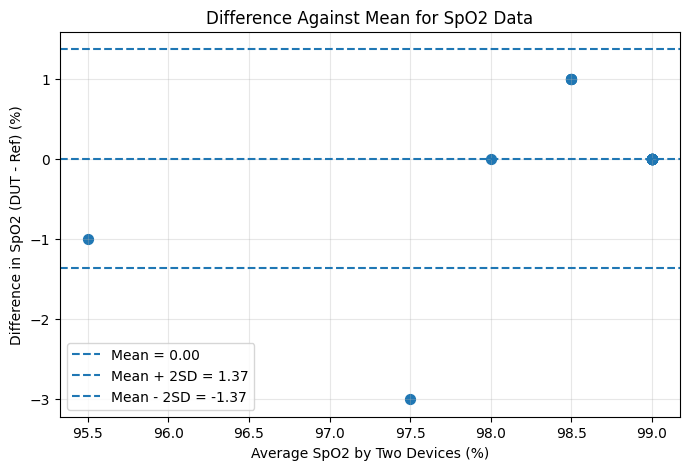

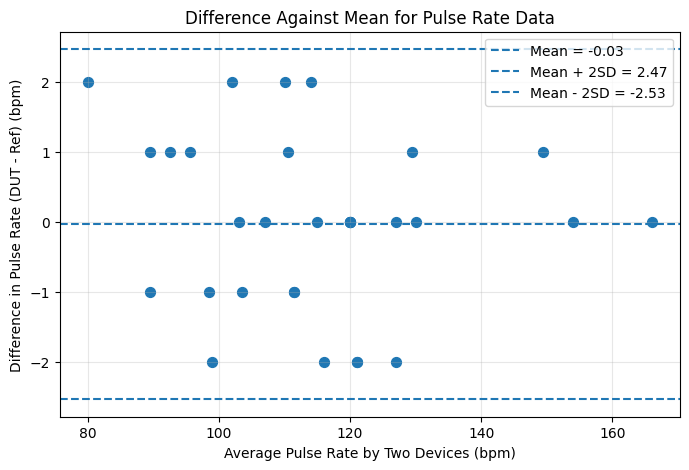

In [2]:

# ==========================================
# IMPORT LIBRARIES
# ==========================================

import numpy as np
import matplotlib.pyplot as plt


# ==========================================
# DATA
# ==========================================

pulso_ref = np.array([
    166, 149, 154, 122, 127, 130, 128, 122,
    117, 115, 120, 120, 101, 99, 90, 79,
    100, 92, 129, 112, 104, 95, 103, 89,
    112, 120, 107, 109, 120, 113, 110
])

spo2_ref = np.array([
    99, 99, 99, 99, 99, 99, 98, 99,
    99, 99, 99, 99, 99, 96, 99, 99,
    99, 99, 98, 99, 98, 99, 99, 99,
    99, 99, 98, 99, 99, 98, 99
])

pulso_dut = np.array([
    166, 150, 154, 120, 127, 130, 126, 120,
    115, 115, 120, 120, 103, 98, 89, 81,
    98, 93, 130, 111, 103, 96, 103, 90,
    111, 120, 107, 111, 120, 115, 111
])

spo2_dut = np.array([
    99, 99, 99, 99, 99, 99, 99, 99,
    99, 99, 99, 99, 99, 95, 99, 99,
    99, 99, 98, 99, 99, 99, 99, 99,
    99, 99, 99, 99, 96, 99, 99
])


# ==========================================
# METRIC CALCULATION FUNCTION
# ==========================================

def calcular_metricas(ref, test):

    diff = test - ref

    Bs = np.mean(diff)

    # Sample standard deviation
    Ps = np.std(diff, ddof=1)

    Arms = np.sqrt(np.mean(diff ** 2))

    As = Bs + Ps

    return diff, Bs, Ps, Arms, As


# ==========================================
# SpO2 METRICS
# ==========================================

diff_spo2, Bs_spo2, Ps_spo2, Arms_spo2, As_spo2 = calcular_metricas(
    spo2_ref,
    spo2_dut
)

print("=== SpO2 RESULTS ===")

print(f"Bias (Bs): {Bs_spo2:.4f} %")

print(f"Precision (Ps): {Ps_spo2:.4f} %")

print(f"Arms: {Arms_spo2:.4f} %")

print(f"As: {As_spo2:.4f} %")

# Verification of Arms relationship
print(
    f"sqrt(Ps² + Bs²): "
    f"{np.sqrt(Ps_spo2**2 + Bs_spo2**2):.4f} %"
)


# ==========================================
# PULSE RATE METRICS
# ==========================================

diff_pulso, Bs_pulso, Ps_pulso, Arms_pulso, As_pulso = calcular_metricas(
    pulso_ref,
    pulso_dut
)

print("\n=== PULSE RATE RESULTS ===")

print(f"Bias (Bs): {Bs_pulso:.4f} bpm")

print(f"Precision (Ps): {Ps_pulso:.4f} bpm")

print(f"Arms: {Arms_pulso:.4f} bpm")

print(f"As: {As_pulso:.4f} bpm")

print(
    f"sqrt(Ps² + Bs²): "
    f"{np.sqrt(Ps_pulso**2 + Bs_pulso**2):.4f} bpm"
)


# ==========================================
# BLAND-ALTMAN PLOT FOR SpO2
# ==========================================

mean_spo2 = (spo2_ref + spo2_dut) / 2

loa_sup_spo2 = Bs_spo2 + 2 * Ps_spo2

loa_inf_spo2 = Bs_spo2 - 2 * Ps_spo2

plt.figure(figsize=(8, 5))

plt.scatter(mean_spo2, diff_spo2, s=50)

plt.axhline(
    Bs_spo2,
    linestyle='--',
    label=f"Mean = {Bs_spo2:.2f}"
)

plt.axhline(
    loa_sup_spo2,
    linestyle='--',
    label=f"Mean + 2SD = {loa_sup_spo2:.2f}"
)

plt.axhline(
    loa_inf_spo2,
    linestyle='--',
    label=f"Mean - 2SD = {loa_inf_spo2:.2f}"
)

plt.xlabel("Average SpO2 by Two Devices (%)")

plt.ylabel("Difference in SpO2 (DUT - Ref) (%)")

plt.title("Difference Against Mean for SpO2 Data")

plt.legend()

plt.grid(True, alpha=0.3)

plt.show()


# ==========================================
# BLAND-ALTMAN PLOT FOR PULSE RATE
# ==========================================

mean_pulso = (pulso_ref + pulso_dut) / 2

loa_sup_pulso = Bs_pulso + 2 * Ps_pulso

loa_inf_pulso = Bs_pulso - 2 * Ps_pulso

plt.figure(figsize=(8, 5))

plt.scatter(mean_pulso, diff_pulso, s=50)

plt.axhline(
    Bs_pulso,
    linestyle='--',
    label=f"Mean = {Bs_pulso:.2f}"
)

plt.axhline(
    loa_sup_pulso,
    linestyle='--',
    label=f"Mean + 2SD = {loa_sup_pulso:.2f}"
)

plt.axhline(
    loa_inf_pulso,
    linestyle='--',
    label=f"Mean - 2SD = {loa_inf_pulso:.2f}"
)

plt.xlabel("Average Pulse Rate by Two Devices (bpm)")

plt.ylabel("Difference in Pulse Rate (DUT - Ref) (bpm)")

plt.title("Difference Against Mean for Pulse Rate Data")

plt.legend()

plt.grid(True, alpha=0.3)

plt.show()

